In [19]:
# ============================================
# 1. Import libraries
# ============================================


import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Hiển thị đầy đủ cột
pd.set_option("display.max_columns", None)

In [20]:
# ============================================
# 2. Load raw data
# ============================================

train_df = pd.read_csv("../data/raw/raw_data_train.csv")
test_df = pd.read_csv("../data/raw/raw_data_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1260428, 19)
Test shape: (315108, 19)


In [21]:
# ============================================
# 3. Chọn các cột cần sử dụng
# ============================================

selected_columns = [
    "name",
    "description",
    "price",
    "area",
    "province_name",
    "district_name",
    "ward_name",
    "floor_count",
    "frontage_width",
    "bedroom_count",
    "bathroom_count",
    "house_direction"
]

train_df = train_df[selected_columns]
test_df = test_df[selected_columns]

print("\nSelected columns:")
print(train_df.columns)


Selected columns:
Index(['name', 'description', 'price', 'area', 'province_name',
       'district_name', 'ward_name', 'floor_count', 'frontage_width',
       'bedroom_count', 'bathroom_count', 'house_direction'],
      dtype='str')


In [22]:
# ============================================
# 4. Kiểm tra missing values
# ============================================

train_missing_percent = (
    train_df.isnull().sum() / len(train_df)
) * 100

test_missing_percent = (
    test_df.isnull().sum() / len(test_df)
) * 100

# Tạo bảng tổng hợp
train_missing_summary = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing Percent": train_missing_percent
})

test_missing_summary = pd.DataFrame({
    "Missing Count": test_df.isnull().sum(),
    "Missing Percent": test_missing_percent
})

# Sắp xếp giảm dần theo % missing
train_missing_summary = train_missing_summary.sort_values(
    by="Missing Percent",
    ascending=False
)

test_missing_summary = test_missing_summary.sort_values(
    by="Missing Percent",
    ascending=False
)

print("\nTrain Missing Value Summary:")
print(train_missing_summary)

print("\nTest Missing Value Summary:")
print(test_missing_summary)




Train Missing Value Summary:
                 Missing Count  Missing Percent
house_direction        1024949        81.317537
floor_count             740715        58.766943
bathroom_count          509368        40.412304
frontage_width          491715        39.011748
bedroom_count           439502        34.869267
ward_name               135613        10.759282
price                    54996         4.363280
district_name            14489         1.149530
name                         0         0.000000
description                  0         0.000000
area                         0         0.000000
province_name                0         0.000000

Test Missing Value Summary:
                 Missing Count  Missing Percent
house_direction         256618        81.438110
floor_count             185002        58.710664
bathroom_count          127075        40.327443
frontage_width          122868        38.992345
bedroom_count           109937        34.888673
ward_name                3385

In [23]:
# ============================================
# 5. Xóa các dòng bị thiếu giá
# và các dòng có price = 0
# ============================================

print("\nBefore dropping missing and zero price:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Xóa missing value của price
train_df = train_df.dropna(subset=["price"])
test_df = test_df.dropna(subset=["price"])

# Xóa các dòng có giá bằng 0
train_df = train_df[train_df["price"] > 0]
test_df = test_df[test_df["price"] > 0]

print("\nAfter dropping missing and zero price:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Kiểm tra lại
# ============================================
# Kiểm tra dòng có price thấp nhất
# ============================================

# Hiển thị full text
pd.set_option("display.max_colwidth", None)

# ===== TRAIN =====
train_min_row = train_df.loc[train_df["price"].idxmin()]

print("===== TRAIN MIN PRICE ROW =====")
print("Name:")
print(train_min_row["name"])

print("\nDescription:")
print(train_min_row["description"])

print("\nPrice:")
print(train_min_row["price"])


# ===== TEST =====
test_min_row = test_df.loc[test_df["price"].idxmin()]

print("\n\n===== TEST MIN PRICE ROW =====")
print("Name:")
print(test_min_row["name"])

print("\nDescription:")
print(test_min_row["description"][503:540])

print("\nPrice:")
print(test_min_row["price"])


Before dropping missing and zero price:
Train shape: (1260428, 12)
Test shape: (315108, 12)

After dropping missing and zero price:
Train shape: (1195187, 12)
Test shape: (298801, 12)
===== TRAIN MIN PRICE ROW =====
Name:
Nhà bán binh mỹ, Huyên cu chi dt: 4 x 13 giá 1.350 triêu lh:

Description:
* BÁN NHÀ BÌNH MỸ, CỦ CHI Vị trí: Khu dân cư đông đúc, hẻm xe hơi Bình Mỹ Củ Chi TP.HCM Diện tích: 4m x 13m ap 5 * Đường 164 hẻm 49 Bình Mỹ .hẻm rộng rãi sạch sẽ xe tải tới nhà Pháp lý: Sổ chung, thổ cư, có giấy phép xây dựng điện nước máy đầy đủ * Giá bán: 1 tỷ 350 triệu (còn bớt lộc Nhà đẹp, vào ở ngay khu vực tiềm năng sinh sống Lh Ba Huân

Price:
1000.0


===== TEST MIN PRICE ROW =====
Name:
Bán nhà 3 tầng 42.6m² hướng Đông Nam, 3 phòng ngủ, ô tô đỗ cửa tại Kiến An, Hải Phòng

Description:
 Giá bán hấp dẫn: 1 tỷ 8xx triệu đồng

Price:
1800000.0


In [24]:
# ============================================
# 6. Xử lý missing values cho numeric columns
# Dùng median vì dữ liệu bất động sản có outlier
# ============================================

numeric_cols = [
    # "floor_count",
    "frontage_width",
    # "bedroom_count",
    "bathroom_count"
]

print("\nMissing values before numeric filling:")
print(train_df[numeric_cols].isnull().sum())

for col in numeric_cols:
    median_value = train_df[col].median()

    train_df[col] = train_df[col].fillna(median_value)
    test_df[col] = test_df[col].fillna(median_value)

print("\nMissing values after numeric filling:")
print(train_df[numeric_cols].isnull().sum())


Missing values before numeric filling:
frontage_width    462764
bathroom_count    490603
dtype: int64

Missing values after numeric filling:
frontage_width    0
bathroom_count    0
dtype: int64


In [25]:
# ============================================
# 6.1 Fill missing floor_count
# ưu tiên quét từ name trước
# nếu không có mới quét description
# ============================================

import re

# ============================================
# Hàm chuẩn hóa text
# ============================================

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # bỏ xuống dòng
    text = text.replace("\n", " ")

    # chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ============================================
# Hàm extract floor_count
# ============================================

def extract_floor_count(text):

    text = clean_text(text)

    # ======================================
    # Case: nhà cấp 4 = 1 tầng
    # ======================================

    if re.search(r'cấp\s*4', text):
        return 1

    # ======================================
    # Case:
    # 5T, 6T
    # ======================================

    match = re.search(r'\b(\d+)\s*t\b', text)

    if match:

        floor = int(match.group(1))

        if 1 <= floor <= 30:
            return floor

    # ======================================
    # Case:
    # 4 tầng
    # ======================================

    match = re.search(r'(\d+)\s*tầng', text)

    if match:

        floor = int(match.group(1))

        if 1 <= floor <= 30:
            return floor

    # ======================================
    # Fallback:
    # lấy tầng lớn nhất
    # từ mô tả tầng
    # ======================================

    floors_found = []

    # --------------------------
    # Case:
    # Tầng 1-3
    # --------------------------

    range_matches = re.findall(
        r'tầng\s*(\d+)\s*[-–]\s*(\d+)',
        text
    )

    for start, end in range_matches:

        floors_found.append(int(start))
        floors_found.append(int(end))

    # --------------------------
    # Case:
    # Tầng 1,2,3
    # --------------------------

    multi_matches = re.findall(
        r'tầng\s*((?:\d+\s*,\s*)+\d+)',
        text
    )

    for item in multi_matches:

        nums = re.findall(r'\d+', item)

        for n in nums:
            floors_found.append(int(n))

    # --------------------------
    # Case:
    # Tầng 4
    # --------------------------

    single_matches = re.findall(
        r'tầng\s*(\d+)',
        text
    )

    for floor in single_matches:

        floors_found.append(int(floor))

    if floors_found:

        max_floor = max(floors_found)

        if 1 <= max_floor <= 30:
            return max_floor

    # ======================================
    # Parse theo kết cấu
    # ======================================

    total = 0

    # --------------------------
    # Hầm
    # --------------------------

    match = re.search(r'(\d+)\s*hầm', text)

    if match:
        total += int(match.group(1))

    elif "hầm" in text:
        total += 1

    # --------------------------
    # Trệt
    # --------------------------

    if "trệt" in text:
        total += 1

    # --------------------------
    # Lửng
    # --------------------------

    match = re.search(r'(\d+)\s*lửng', text)

    if match:
        total += int(match.group(1))

    elif "lửng" in text:
        total += 1

    # --------------------------
    # Lầu
    # --------------------------

    match = re.search(r'(\d+)\s*lầu', text)

    if match:
        total += int(match.group(1))

    elif "lầu" in text:
        total += 1

    # --------------------------
    # Gác
    # --------------------------

    match = re.search(r'(\d+)\s*gác', text)

    if match:
        total += int(match.group(1))

    elif "gác" in text:
        total += 1

    # ======================================
    # Return result
    # ======================================

    if 1 <= total <= 30:
        return total

    return np.nan


# ============================================
# Hàm extract ưu tiên NAME trước
# ============================================

def extract_floor_from_name_desc(name, desc):

    # --------------------------
    # Ưu tiên quét name trước
    # --------------------------

    floor_from_name = extract_floor_count(name)

    if not pd.isna(floor_from_name):
        return floor_from_name

    # --------------------------
    # Nếu name không có
    # mới quét description
    # --------------------------

    return extract_floor_count(desc)


# ============================================
# Thống kê trước xử lý
# ============================================

print("\n===== FLOOR_COUNT BEFORE PROCESSING =====")

train_floor_null_before = (
    train_df["floor_count"].isnull().sum()
)

test_floor_null_before = (
    test_df["floor_count"].isnull().sum()
)

train_floor_null_percent_before = (
    train_floor_null_before / len(train_df)
) * 100

test_floor_null_percent_before = (
    test_floor_null_before / len(test_df)
) * 100

print(f"Train null count: {train_floor_null_before}")
print(f"Train null percent: {train_floor_null_percent_before:.2f}%")

print(f"Test null count: {test_floor_null_before}")
print(f"Test null percent: {test_floor_null_percent_before:.2f}%")


# ============================================
# Mask missing
# ============================================

train_mask = (
    train_df["floor_count"].isnull()
)

test_mask = (
    test_df["floor_count"].isnull()
)


# ============================================
# Lưu sample trước fill
# ============================================

sample_before_fill = train_df.loc[
    train_mask,
    ["name", "description", "area", "price", "floor_count"]
].head(30).copy()


# ============================================
# Fill train
# ============================================

train_extracted = train_df.loc[
    train_mask
].apply(
    lambda row: extract_floor_from_name_desc(
        row["name"],
        row["description"]
    ),
    axis=1
)

train_extracted = pd.to_numeric(
    train_extracted,
    errors="coerce"
)

train_df.loc[
    train_mask,
    "floor_count"
] = train_extracted


# ============================================
# Fill test
# ============================================

test_extracted = test_df.loc[
    test_mask
].apply(
    lambda row: extract_floor_from_name_desc(
        row["name"],
        row["description"]
    ),
    axis=1
)

test_extracted = pd.to_numeric(
    test_extracted,
    errors="coerce"
)

test_df.loc[
    test_mask,
    "floor_count"
] = test_extracted


# ============================================
# Thống kê sau xử lý
# ============================================

print("\n===== FLOOR_COUNT AFTER PROCESSING =====")

train_floor_null_after = (
    train_df["floor_count"].isnull().sum()
)

test_floor_null_after = (
    test_df["floor_count"].isnull().sum()
)

train_floor_null_percent_after = (
    train_floor_null_after / len(train_df)
) * 100

test_floor_null_percent_after = (
    test_floor_null_after / len(test_df)
) * 100

print(f"Train null count: {train_floor_null_after}")
print(f"Train null percent: {train_floor_null_percent_after:.2f}%")

print(f"Test null count: {test_floor_null_after}")
print(f"Test null percent: {test_floor_null_percent_after:.2f}%")


# ============================================
# Số lượng đã fill
# ============================================

train_filled = (
    train_floor_null_before
    - train_floor_null_after
)

test_filled = (
    test_floor_null_before
    - test_floor_null_after
)

print("\n===== FILLED FLOOR_COUNT =====")

print(f"Train filled rows: {train_filled}")
print(f"Test filled rows: {test_filled}")


# ============================================
# Sample sau fill
# ============================================

sample_after_fill = train_df.loc[
    sample_before_fill.index,
    ["name", "description", "area","price", "floor_count"]
]


# ============================================
# Hiển thị full text
# ============================================

pd.set_option(
    "display.max_colwidth",
    None
)


# ============================================
# BEFORE
# ============================================

print("\n===== BEFORE FILL =====")

for idx, row in sample_before_fill.iterrows():

    print(f"\nIndex: {idx}")

    print(f"Floor count: {row['floor_count']}")

    print(f"Name: {row['name']}")

    print(f"Area: {row['area']}")
    print(f"Price: {row['price']}")

    print("Description:")
    print(row["description"])

    print("-" * 120)


# ============================================
# AFTER
# ============================================

print("\n===== AFTER FILL =====")

for idx, row in sample_after_fill.iterrows():

    print(f"\nIndex: {idx}")

    print(f"Floor count: {row['floor_count']}")

    print(f"Name: {row['name']}")
    print(f"Area: {row['area']}")
    print(f"Price: {row['price']}")

    print("Description:")
    print(row["description"])

    print("-" * 120)


===== FLOOR_COUNT BEFORE PROCESSING =====
Train null count: 715617
Train null percent: 59.87%
Test null count: 178757
Test null percent: 59.82%

===== FLOOR_COUNT AFTER PROCESSING =====
Train null count: 93937
Train null percent: 7.86%
Test null count: 23564
Test null percent: 7.89%

===== FILLED FLOOR_COUNT =====
Train filled rows: 621680
Test filled rows: 155193

===== BEFORE FILL =====

Index: 2
Floor count: nan
Name: Bán nhà mặt phố tại Hoàng Hoa Thám, 16,5 tỷ, 56,55 m2, 3PN + 3WC + 4 tầng, Chính chủ
Area: 56.55
Price: 16500000000.0
Description:
Nhà mặt phố Đường Hoàng Hoa Thám, Phường Nha Trang, Khánh Hòa (Thành phố Nha Trang, Khánh Hòa cũ) có vị trí đắc địa, diện tích 56,55 m2, gồm 3 phòng ngủ + 3WC + 4 tầng, hướng cửa chính Nam. Nhà được thiết kế hiện đại, pháp lý đầy đủ, thích hợp cho việc kinh doanh hoặc sinh sống. Nội thất cơ bản với điều hòa, tủ lạnh, giường. Ngõ vào rộng 20m, thuận tiện cho xe hơi. Điểm đặc sắc: + 3PN + 3WC + bếp + Giá: 16,5 tỷ VND + Nội thất: điều hòa, tủ

In [26]:
# ============================================
# 6.2 Fill missing bedroom_count from description
# ============================================



# ============================================
# Đảm bảo bedroom_count là numeric
# ============================================

train_df["bedroom_count"] = pd.to_numeric(
    train_df["bedroom_count"],
    errors="coerce"
)

test_df["bedroom_count"] = pd.to_numeric(
    test_df["bedroom_count"],
    errors="coerce"
)




# ============================================
# Hàm extract bedroom_count
# ============================================

def extract_bedroom_count(desc):

    desc = clean_text(desc)



    # # ======================================
    # # PRIORITY 2
    # # Tầng 2.3.4: mỗi tầng 1 ngủ
    # # ======================================

    # range_match = re.search(
        # r'tầng\s*(\d+)\s*[.\-–]\s*(\d+).*?mỗi tầng\s*(\d+)\s*ngủ',
    #     desc
    # )

    # if range_match:

    #     start_floor = int(range_match.group(1))
    #     end_floor = int(range_match.group(2))
    #     each_floor_bedroom = int(range_match.group(3))

    #     total_floors = end_floor - start_floor + 1

    #     bedroom = total_floors * each_floor_bedroom

    #     if 1 <= bedroom <= 30:
    #         return bedroom

    # ======================================
    # PRIORITY 3
    # Tầng 2, 3, 4: mỗi tầng 2 phòng ngủ
    # ======================================

    multi_floor_match = re.search(
        # r'tầng\s*((?:\d+\s*[,.\-]\s*)+\d+).*?mỗi tầng\s*(\d+)\s*(?:phòng ngủ|pn|ngủ)',
        r'tầng\s*((?:\d+\s*[,.\-]\s*)+\d+)\s*[:\-–]?\s*.*?mỗi tầng\s*(\d+)\s*(?:phòng ngủ|pn|ngủ)',
        desc
    )

    if multi_floor_match:

        floors_text = multi_floor_match.group(1)

        each_floor_bedroom = int(
            multi_floor_match.group(2)
        )

        # lấy danh sách tầng
        floors = re.findall(r'\d+', floors_text)

        total_floors = len(floors)

        bedroom = total_floors * each_floor_bedroom

        # ==================================
        # cộng thêm tầng riêng lẻ phía sau
        # ví dụ:
        # tầng 5: 1 phòng ngủ
        # ==================================

        extra_matches = re.findall(
            r'tầng\s*\d+.*?(\d+)\s*(?:phòng ngủ|ngủ|pn)',
            desc
        )

        if extra_matches:

            extra_nums = [
                int(x) for x in extra_matches
            ]

            bedroom += sum(extra_nums)

            # tránh double count
            bedroom -= each_floor_bedroom

        if 1 <= bedroom <= 30:
            return bedroom

        # ==================================
        # cộng thêm tầng riêng lẻ phía sau
        # ví dụ:
        # tầng 5: 1 phòng ngủ
        # ==================================

        extra_matches = re.findall(
            r'tầng\s*\d+.*?(\d+)\s*(?:phòng ngủ|ngủ|pn)',
            desc
        )

        if extra_matches:

            extra_nums = [
                int(x) for x in extra_matches
            ]

            bedroom += sum(extra_nums)

            # tránh double count
            bedroom -= each_floor_bedroom

        if 1 <= bedroom <= 30:
            return bedroom

    # ======================================
    # PRIORITY 1
    # 4PN
    # 3 phòng ngủ
    # 4 ngủ
    # ======================================

    patterns = [

        r'\b(\d+)\s*pn\b',

        r'(\d+)\s*phòng ngủ',

        r'(\d+)\s*ngủ'
    ]

    for pattern in patterns:

        match = re.search(pattern, desc)

        if match:

            bedroom = int(match.group(1))

            # tránh giá trị vô lý
            if 1 <= bedroom <= 30:
                return bedroom



    # ======================================
    # PRIORITY 4
    # lấy max nếu có nhiều số ngủ
    # ======================================

    matches = re.findall(
        r'(\d+)\s*ngủ',
        desc
    )

    if matches:

        nums = [int(x) for x in matches]

        bedroom = max(nums)

        if 1 <= bedroom <= 30:
            return bedroom

    return np.nan


# ============================================
# Thống kê trước xử lý
# ============================================

print("\n===== BEDROOM_COUNT BEFORE PROCESSING =====")

train_bedroom_null_before = (
    train_df["bedroom_count"].isnull().sum()
)

test_bedroom_null_before = (
    test_df["bedroom_count"].isnull().sum()
)

train_bedroom_null_percent_before = (
    train_bedroom_null_before / len(train_df)
) * 100

test_bedroom_null_percent_before = (
    test_bedroom_null_before / len(test_df)
) * 100

print(f"Train null count: {train_bedroom_null_before}")
print(f"Train null percent: {train_bedroom_null_percent_before:.2f}%")

print(f"Test null count: {test_bedroom_null_before}")
print(f"Test null percent: {test_bedroom_null_percent_before:.2f}%")


# ============================================
# Mask các dòng bị thiếu
# ============================================

train_bedroom_mask = (
    train_df["bedroom_count"].isnull()
)

test_bedroom_mask = (
    test_df["bedroom_count"].isnull()
)


# ============================================
# Lưu 20 dòng trước khi fill
# ============================================

sample_bedroom_before_fill = train_df.loc[
    train_bedroom_mask,
    ["name","description","area","price","floor_count", "bedroom_count"]
].head(20).copy()


# ============================================
# Extract train
# ============================================

train_bedroom_extracted = (
    train_df.loc[
        train_bedroom_mask,
        "description"
    ]
    .apply(extract_bedroom_count)
)

# ép numeric
train_bedroom_extracted = pd.to_numeric(
    train_bedroom_extracted,
    errors="coerce"
)

# fill
train_df.loc[
    train_bedroom_mask,
    "bedroom_count"
] = train_bedroom_extracted


# ============================================
# Extract test
# ============================================

test_bedroom_extracted = (
    test_df.loc[
        test_bedroom_mask,
        "description"
    ]
    .apply(extract_bedroom_count)
)

test_bedroom_extracted = pd.to_numeric(
    test_bedroom_extracted,
    errors="coerce"
)

test_df.loc[
    test_bedroom_mask,
    "bedroom_count"
] = test_bedroom_extracted


# ============================================
# Lấy lại đúng 20 dòng đó sau khi fill
# ============================================

sample_bedroom_after_fill = train_df.loc[
    sample_bedroom_before_fill.index,
    ["name","description","area","price","floor_count", "bedroom_count"]
]


# ============================================
# Thống kê sau xử lý
# ============================================

print("\n===== BEDROOM_COUNT AFTER PROCESSING =====")

train_bedroom_null_after = (
    train_df["bedroom_count"].isnull().sum()
)

test_bedroom_null_after = (
    test_df["bedroom_count"].isnull().sum()
)

train_bedroom_null_percent_after = (
    train_bedroom_null_after / len(train_df)
) * 100

test_bedroom_null_percent_after = (
    test_bedroom_null_after / len(test_df)
) * 100

print(f"Train null count: {train_bedroom_null_after}")
print(f"Train null percent: {train_bedroom_null_percent_after:.2f}%")

print(f"Test null count: {test_bedroom_null_after}")
print(f"Test null percent: {test_bedroom_null_percent_after:.2f}%")


# ============================================
# Số lượng đã fill
# ============================================

train_bedroom_filled = (
    train_bedroom_null_before
    - train_bedroom_null_after
)

test_bedroom_filled = (
    test_bedroom_null_before
    - test_bedroom_null_after
)

print("\n===== FILLED BEDROOM_COUNT =====")

print(f"Train filled rows: {train_bedroom_filled}")
print(f"Test filled rows: {test_bedroom_filled}")


# ============================================
# Hiển thị full description
# ============================================

pd.set_option("display.max_colwidth", None)


# ============================================
# BEFORE FILL
# ============================================

print("\n===== SAMPLE BEFORE FILL =====")

for idx, row in sample_bedroom_before_fill.iterrows():

    print(f"\nIndex: {idx}")

    print(f"Bedroom count: {row['bedroom_count']}")
    print(f"Floor count: {row['floor_count']}")
    print(f"Name: {row['name']}")
    print(f"Area: {row['area']}")
    print(f"Price: {row['price']}")

    print("Description:")
    print(row["description"])

    print("-" * 120)


# ============================================
# AFTER FILL
# ============================================

print("\n===== SAMPLE AFTER FILL =====")

for idx, row in sample_bedroom_after_fill.iterrows():

    print(f"\nIndex: {idx}")

    print(f"Bedroom count: {row['bedroom_count']}")
    print(f"Floor count: {row['floor_count']}")
    print(f"Name: {row['name']}")
    print(f"Area: {row['area']}")
    print(f"Price: {row['price']}")

    print("Description:")
    print(row["description"])

    print("-" * 120)


===== BEDROOM_COUNT BEFORE PROCESSING =====
Train null count: 423626
Train null percent: 35.44%
Test null count: 106058
Test null percent: 35.49%

===== BEDROOM_COUNT AFTER PROCESSING =====
Train null count: 322527
Train null percent: 26.99%
Test null count: 80581
Test null percent: 26.97%

===== FILLED BEDROOM_COUNT =====
Train filled rows: 101099
Test filled rows: 25477

===== SAMPLE BEFORE FILL =====

Index: 3
Bedroom count: nan
Floor count: 4.0
Name: Bán NR Trường Sa, 5,6 tỷ, 32m2, Q3, HCM
Area: 32.0
Price: 5600000000.0
Description:
Mô tả chi tiết về căn nhà riêng này tại Trường Sa, Q3, HCM. Nhà 4 tầng, diện tích 32m2, giá chỉ 5,6 tỷ VND. Pháp lý đầy đủ, phong thủy tốt, đảm bảo an toàn và tiện nghi cho cuộc sống. Căn nhà có thiết kế hiện đại, không gian thoáng đãng, rất phù hợp cho gia đình trẻ hoặc những ai yêu thích sự riêng tư. Được xây dựng chắc chắn, đảm bảo tính bền vững và an toàn cho người sử dụng. Căn nhà nằm ở vị trí thuận lợi, gần nhiều tiện ích như bệnh viện tai mũi họ

In [27]:
# ============================================
# 7. Xử lý missing values cho categorical columns
# ============================================

# --------------------------------------------
# 7.1 Fill district_name bằng province + ward
# --------------------------------------------

categorical_cols = [
    "district_name",
    "ward_name",
    "house_direction"
]

print("\nTraining missing values before categorical filling:")
print(train_df[categorical_cols].isnull().sum())


mapping = (
    train_df
    .dropna(subset=["district_name", "ward_name"])
    .groupby(["province_name", "ward_name"])["district_name"]
    .agg(lambda x: x.mode()[0])
)

def fill_district(row):
    if pd.isna(row["district_name"]):
        key = (row["province_name"], row["ward_name"])

        if key in mapping:
            return mapping[key]

    return row["district_name"]

train_df["district_name"] = train_df.apply(
    fill_district,
    axis=1
)

test_df["district_name"] = test_df.apply(
    fill_district,
    axis=1
)

# --------------------------------------------
# 7.2 Fill các categorical columns còn lại
# --------------------------------------------



# for col in categorical_cols:
#     train_df[col] = train_df[col].fillna("Unknown")
#     test_df[col] = test_df[col].fillna("Unknown")

print("\nTraining missing values after categorical filling:")
print(train_df[categorical_cols].isnull().sum())


Training missing values before categorical filling:
district_name       13225
ward_name          128269
house_direction    965888
dtype: int64

Training missing values after categorical filling:
district_name       13225
ward_name          128269
house_direction    965888
dtype: int64


In [28]:
# ============================================
# 8. Xóa duplicate rows
# ============================================

print("\nBefore removing duplicates:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)

train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("\nAfter removing duplicates:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)


Before removing duplicates:
Train: (1195187, 12)
Test: (298801, 12)

After removing duplicates:
Train: (1119580, 12)
Test: (293159, 12)


In [29]:
# ============================================
# 9. Xử lý outliers cho price
# Giữ dữ liệu từ 1% đến 99%
# ============================================

q1 = train_df["price"].quantile(0.01)
q99 = train_df["price"].quantile(0.99)

train_df = train_df[
    (train_df["price"] >= q1) &
    (train_df["price"] <= q99)
]

print("\nAfter removing outliers:")
print("Train shape:", train_df.shape)

# Kiểm tra lại
print("\nMinimum train price:", train_df["price"].min())
print("Minimum test price:", test_df["price"].min())


After removing outliers:
Train shape: (1097317, 12)

Minimum train price: 1430000000.0
Minimum test price: 1800000.0


In [30]:
# ============================================
# 10. Xử lý outliers cho area
# ============================================

q1_area = train_df["area"].quantile(0.01)
q99_area = train_df["area"].quantile(0.99)

train_df = train_df[
    (train_df["area"] >= q1_area) &
    (train_df["area"] <= q99_area)
]

print("\nAfter removing area outliers:")
print("Train shape:", train_df.shape)




After removing area outliers:
Train shape: (1077929, 12)


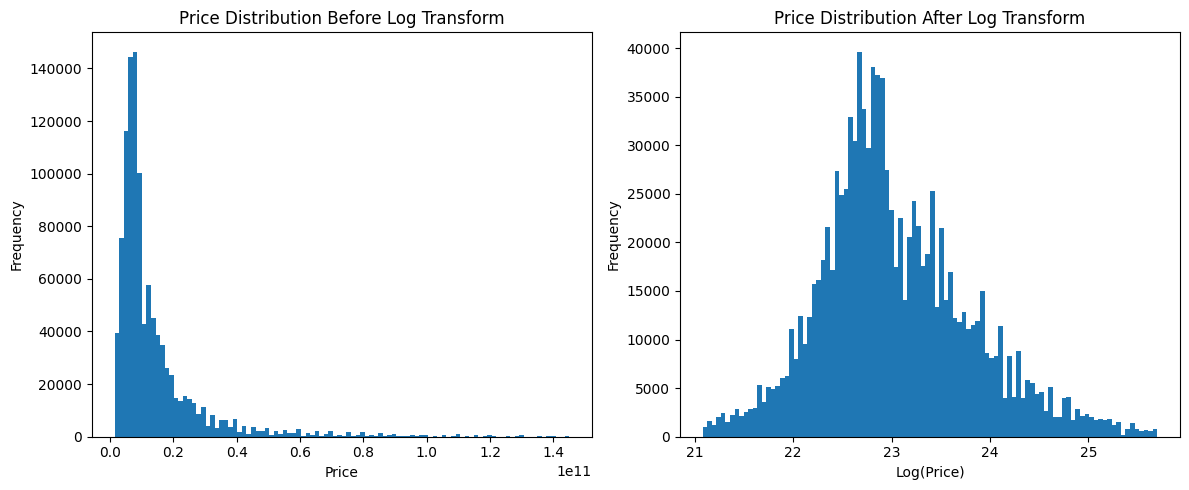


Price transformed using log1p


In [31]:
# ============================================
# 11. Log transform target
# Hiển thị phân phối trước và sau log transform
# ============================================

# Backup dữ liệu gốc trước khi transform
original_price = train_df["price"].copy()

# --------------------------------------------
# Vẽ phân phối trước khi log transform
# --------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(original_price, bins=100)

plt.title("Price Distribution Before Log Transform")
plt.xlabel("Price")
plt.ylabel("Frequency")

# --------------------------------------------
# Log transform
# --------------------------------------------

train_df["price"] = np.log1p(train_df["price"])
test_df["price"] = np.log1p(test_df["price"])

# --------------------------------------------
# Vẽ phân phối sau khi log transform
# --------------------------------------------

plt.subplot(1, 2, 2)

plt.hist(train_df["price"], bins=100)

plt.title("Price Distribution After Log Transform")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

# --------------------------------------------
# Hiển thị biểu đồ
# --------------------------------------------

plt.tight_layout()
plt.show()

print("\nPrice transformed using log1p")

In [32]:
# ============================================
# 12. Reset index
# ============================================

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [33]:
# ============================================
# 13. Kiểm tra dữ liệu sau cleaning
# ============================================

print("\nTrain info:")
print(train_df.info())

print("\nTest info:")
print(test_df.info())

print("\nTrain describe:")
print(train_df.describe())


Train info:


<class 'pandas.DataFrame'>
RangeIndex: 1077929 entries, 0 to 1077928
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   name             1077929 non-null  str    
 1   description      1077929 non-null  str    
 2   price            1077929 non-null  float64
 3   area             1077929 non-null  float64
 4   province_name    1077929 non-null  str    
 5   district_name    1065350 non-null  str    
 6   ward_name        959224 non-null   str    
 7   floor_count      996778 non-null   float64
 8   frontage_width   1077929 non-null  float64
 9   bedroom_count    799571 non-null   float64
 10  bathroom_count   1077929 non-null  float64
 11  house_direction  211773 non-null   str    
dtypes: float64(6), str(6)
memory usage: 899.5 MB
None

Test info:
<class 'pandas.DataFrame'>
RangeIndex: 293159 entries, 0 to 293158
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------ 

In [34]:
# ============================================
# 14. Kiểm tra missing values cuối cùng
# ============================================

print("\nFinal missing values in train:")
print(train_df.isnull().sum())

print("\nFinal missing values in test:")
print(test_df.isnull().sum())


Final missing values in train:
name                    0
description             0
price                   0
area                    0
province_name           0
district_name       12579
ward_name          118705
floor_count         81151
frontage_width          0
bedroom_count      278358
bathroom_count          0
house_direction    866156
dtype: int64

Final missing values in test:
name                    0
description             0
price                   0
area                    0
province_name           0
district_name        3294
ward_name           31557
floor_count         23251
frontage_width          0
bedroom_count       78486
bathroom_count          0
house_direction    236815
dtype: int64


In [35]:
# ============================================
# 15. Save clean data
# ============================================

train_df.to_csv(
    "../data/clean/clean_data_train.csv",
    index=False
)

test_df.to_csv(
    "../data/clean/clean_data_test.csv",
    index=False
)

print("\nCleaned data saved successfully!")


Cleaned data saved successfully!


In [36]:
# ============================================
# 16. Final shapes
# ============================================

print("\nFinal dataset shapes:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)


Final dataset shapes:
Train: (1077929, 12)
Test: (293159, 12)
